In [ ]:
##################################################
#
# NEURAL NETWORK (1 HIDDEN LAYER, REGRESSION)
#
#################################################
#
# Neural network is nested compositon of functions - f(x) = f_L(...f_2(f_1(x)))
# Where weights are obtained via backpropogation
# Backprop is reverse-mode auto differentiation - uses the directed acyclic graph structure to avoid recomputation
# Gradient of loss wrt weights of any layer would depend on all layers between that layer and output
#
# The decision boundary here isnt a hyperplane - its piecewise linear function (ReLU) or smooth nonlinear manifold (sigmoid)
# Capacity isnt controlled by parameter count alone now, its controlled by how many pieces the function can break into
# NN can overfit even with few parameters, and why margin theory alone doesn't explain generalization.
#
# NN can have depth (many layers) or width (many units per layer)
# Depth allows hierarchial feature compostion
# Width at layer 1: learns h different linear combinations of x.
# Depth (layer 2 uses layer 1's output): learns combinations of combinations.
# Ex: Layer 1 learns edges , 2 learns corners, 3 learns shapes
# A 3 layer network can represent some functions that a 2 layer network needs exponentially many units to represent
#
# NN uses smooth activations to get gradients to flow backwards
# sigmoid / tanh have gradients that vanish when inputs are too large (above a saturation limit)
# If weights push activations into saturation zone (some |z| >= c) gradients die -> no updation occurs
# ReLU fixes this for positive inputs, for negative it gives dead neurons
# These conditioning issues, to solve need to look at stuff gradients depend on
# Gradient magnitude depends on product of weight matrices - ∂L/∂W1 involves (W2^T)(W3^T)...(W_L^T) times something - singular values matter
# If largest singular value (spectral norm) > 1 grad grows, < 1 grad shrinks.
# We can control how these are initialized : He initialization: W ~ N(0, 2/fan_in) for ReLU, Xavier: W ~ N(0, 1/fan_in) for sigmoid/tanh.
# Goal is variance preservation across layers 
#
# NN loss landscape is non-convex -> same functions represented by many weights -> creates saddle points
# SGD, empirically should find good solutions as it can escape saddle points / narrow solutions
# 
# Diagnostic metrics to log during training:
# 1. Loss (train and val)
# 2. Gradient norms: ||∂L/∂W1||, ||∂L/∂W2||
# 3. Activation statistics: mean, variance, % zeros (for ReLU)
# 4. Weight norms: ||W1||, ||W2||
#
# If ||∂L/∂W1|| -> 0: vanishing gradients
# If ||∂L/∂W1|| -> ∞: exploding gradients
# If % zeros > 90%: dying ReLU
# If train loss ≪ val loss: overfitting
# If both high: underfitting
#
#
# Hypothesis class:
# f(x; W1, b1, W2, b2) = W2 * σ(W1*x + b1) + b2
#
# f is a non-linear differentiable function
# MSE loss with L2 regulaisation (same strength) used here
# 
# ReLU - Rectified linear unit:
# σ(z) = max(0, z)
# σ'(z) = 1 if z > 0 else 0
# No saturation for z > 0
# Gradient is 1 - not shrinking
# Computationally cheap
# Dead neurons if z <= 0 always

In [3]:
# Backprop works becuase of its Computational graph structure and DAG
# Removing bias term would shrink Hypothesis class - non origin centered data wont fit
# Wrong activations - gradients explosion/vanishing , computation cost
# Shuffle data -> SGD wont see correlated samples -> faster convergence
# Batch normalize -> implicit regularisation

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class NeuralNetwork:
    def __init__(self, input_dim, hidden_dim, lr=0.01, reg_str=0.0,keep_prob=0.8):
        """
        Input:  X ∈ R^(n × d)      — n samples, d features
        W1:     W1 ∈ R^(h × d)     — first layer weights
        b1:     b1 ∈ R^h           — first layer bias
        z1:     z1 ∈ R^(n × h)     — pre-activation hidden
        a1:     a1 ∈ R^(n × h)     — post-activation hidden
        W2:     W2 ∈ R^(h × 1)     — output weights , column vector 
        b2:     b2 ∈ R             — output bias , scalar
        y_hat:  y_hat ∈ R^(n × 1)  — predictions

        He Initialisation
        General Variance:  Var(z) = d * Var(W) * Var(x)
        With ReLU:         Var(z) = d * Var(W) * [1/2 * Var(x)]
        Goal:              Var(z) = Var(x)
        Gives              Var(W) = 2 / d

        Momentum - Exponential Moving Average 
        """
        self.lr = lr 
        self.reg_str = reg_str
        self.keep_prob = keep_prob
        self.W1 = np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2.0 / hidden_dim)
        self.b2 = 0.0

        
        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = 0.0
        self.beta = 0.5
        self.history = {
            'loss': [], 'grad_norm_W1': [], 'grad_norm_W2': [],'a1_mean': [], 'a1_var': [], 'a1_zero_pct': [],'w1_norm': [], 'w2_norm': []
        }

    def relu(self,z):
        return np.maximum(0,z)
    def relu_deriv(self,z):
        return (z>0).astype(float)
    
    def _log_metrics(self, loss, dL_dW1, dL_dW2):

        self.history['loss'].append(loss)
        self.history['grad_norm_W1'].append(np.linalg.norm(dL_dW1))
        self.history['grad_norm_W2'].append(np.linalg.norm(dL_dW2))
        self.history['w1_norm'].append(np.linalg.norm(self.W1))
        self.history['w2_norm'].append(np.linalg.norm(self.W2))
        

        self.history['a1_mean'].append(np.mean(self.a1))
        self.history['a1_var'].append(np.var(self.a1))
        self.history['a1_zero_pct'].append(np.mean(self.a1 == 0))
    
    def forward(self,X,training=True):
        """
        Forward pass
        z1 = X @ W1.T + b1           (n × d) @ (d × h) = (n × h)
        a1 = σ(z1)                   element-wise activation
        z2 = a1 @ W2 + b2            (n × h) @ (h × 1) = (n × 1)
        y_hat = z2                   no output activation for regression

        """
        self.X = X
        self.z1 = X @ self.W1.T + self.b1 
        self.a1 = self.relu(self.z1)
        if training and self.keep_prob < 1.0:
            self.drop_mask = (np.random.rand(*self.a1.shape) < self.keep_prob) / self.keep_prob
            self.a1 *= self.drop_mask
        
        self.z2 = self.a1 @ self.W2 + self.b2
        return self.z2

    
    def mse_reg_loss(self,y_pred,y):
        """ 
        MSE Loss 
        L = (1/n) * sum((y_pred - y)²)
        
        L2 regularisation
        L_total = L_data + (λ/2) * (||W1||² + ||W2||²)
        ∂L/∂W1 ← ∂L/∂W1 + λ * W1
        ∂L/∂W2 ← ∂L/∂W2 + λ * W2

        """

        mse_loss  = np.mean((y_pred-y)**2)
        reg_loss  = (self.reg_str/2.0) * (np.sum(self.W1 **2) + np.sum(self.W2**2))
        return mse_loss + reg_loss
    
    def backward(self,y_pred,y):
        
        n = len(y)

        # δ2 = (2/n) * (y_hat - y)          # (n × 1)
        dL_dz2 = (2.0/n) * (y_pred - y)

        # ∂L/∂W2 = a1.T @ δ2 + (reg_2 * W2) # (h × n) @ (n × 1) = (h × 1)
        # ∂L/∂b2 = sum(δ2)                  # scalar
        dL_dW2= self.a1.T @ dL_dz2 + self.reg_str * self.W2
        dL_db2 = np.sum(dL_dz2)

        # ∂L/∂a1 = δ2 @ W2.T                # (n × 1) @ (1 × h) = (n × h)
        # δ1 = ∂L/∂a1 ⊙ σ'(z1)             # (n × h) element-wise
        dL_da1 = dL_dz2 @ self.W2.T
        if hasattr(self, 'drop_mask'):
            dL_da1 *= self.drop_mask
        dL_dz1 = dL_da1 * self.relu_deriv(self.z1)

        # ∂L/∂W1 = δ1.T @ X (reg_1 * W1)    # (h × n) @ (n × d) = (h × d)
        # ∂L/∂b1 = sum(δ1, axis=0)          # (h,)
        dL_dW1 = dL_dz1.T @ self.X + self.reg_str * self.W1
        dL_db1 = np.sum(dL_dz1,axis=0)

        current_loss = self.mse_reg_loss(y_pred, y)
        self._log_metrics(current_loss, dL_dW1, dL_dW2)
        
        self.v_W1 = self.beta * self.v_W1 + (1 - self.beta) * dL_dW1
        self.v_W2 = self.beta * self.v_W2 + (1 - self.beta) * dL_dW2
        self.v_b1 = self.beta * self.v_b1 + (1 - self.beta) * dL_db1
        self.v_b2 = self.beta * self.v_b2 + (1 - self.beta) * dL_db2
        self.W1 -= self.lr * self.v_W1
        self.b1 -= self.lr * self.v_b1
        self.W2 -= self.lr * self.v_W2
        self.b2 -= self.lr * self.v_b2

    def fit(self, X, y, epochs=1000,verbose = True):
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        losses = []
        for epoch in range(epochs):
            y_hat = self.forward(X)
            loss = self.mse_reg_loss(y_hat, y)
            losses.append(loss)
            self.backward(y_hat, y)
            
            if verbose and epoch%500 == 0:
                print(f"[x] Epoch : {epoch} | Loss  : {loss}")
            
        return losses
    def fit_sgd(self, X, y, epochs, batch_size=32,verbose=True):
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        n = len(X)
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            indices = np.random.permutation(n)
            for i in range(0, n, batch_size):
                batch_idx = indices[i:i+batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                
                y_pred = self.forward(X_batch)
                loss = self.mse_reg_loss(y_pred, y_batch)
                epoch_losses.append(loss)
                self.backward(y_pred, y_batch)

            epoch_mean_loss = np.mean(epoch_losses)
            losses.append(epoch_mean_loss)
            if verbose and epoch%500==0:    
                print(f"[x] Epoch : {epoch} Loss (SGD Batches Mean) : {loss}")
        return losses
    
    def predict(self, X):
        return self.forward(X,training=False)

In [6]:
np.random.seed(42)
X = np.random.uniform(-3, 3, (200, 1))
y = X**2 + np.random.normal(0, 0.5, (200, 1))
X_train, y_train = X[:150], y[:150]
X_test, y_test = X[150:], y[150:]


Config: GD | Test MSE: 0.267596
Config: SGD | Test MSE: 0.205629
Config: GD + Mom | Test MSE: 0.385701
Config: SGD + Mom | Test MSE: 0.185332
Config: Mom+Drop+SGD | Test MSE: 0.400381
Config: Mom+Drop+GD | Test MSE: 0.428905
Config: Drop+SGD | Test MSE: 0.373919
Config: Drop+GD | Test MSE: 0.333777


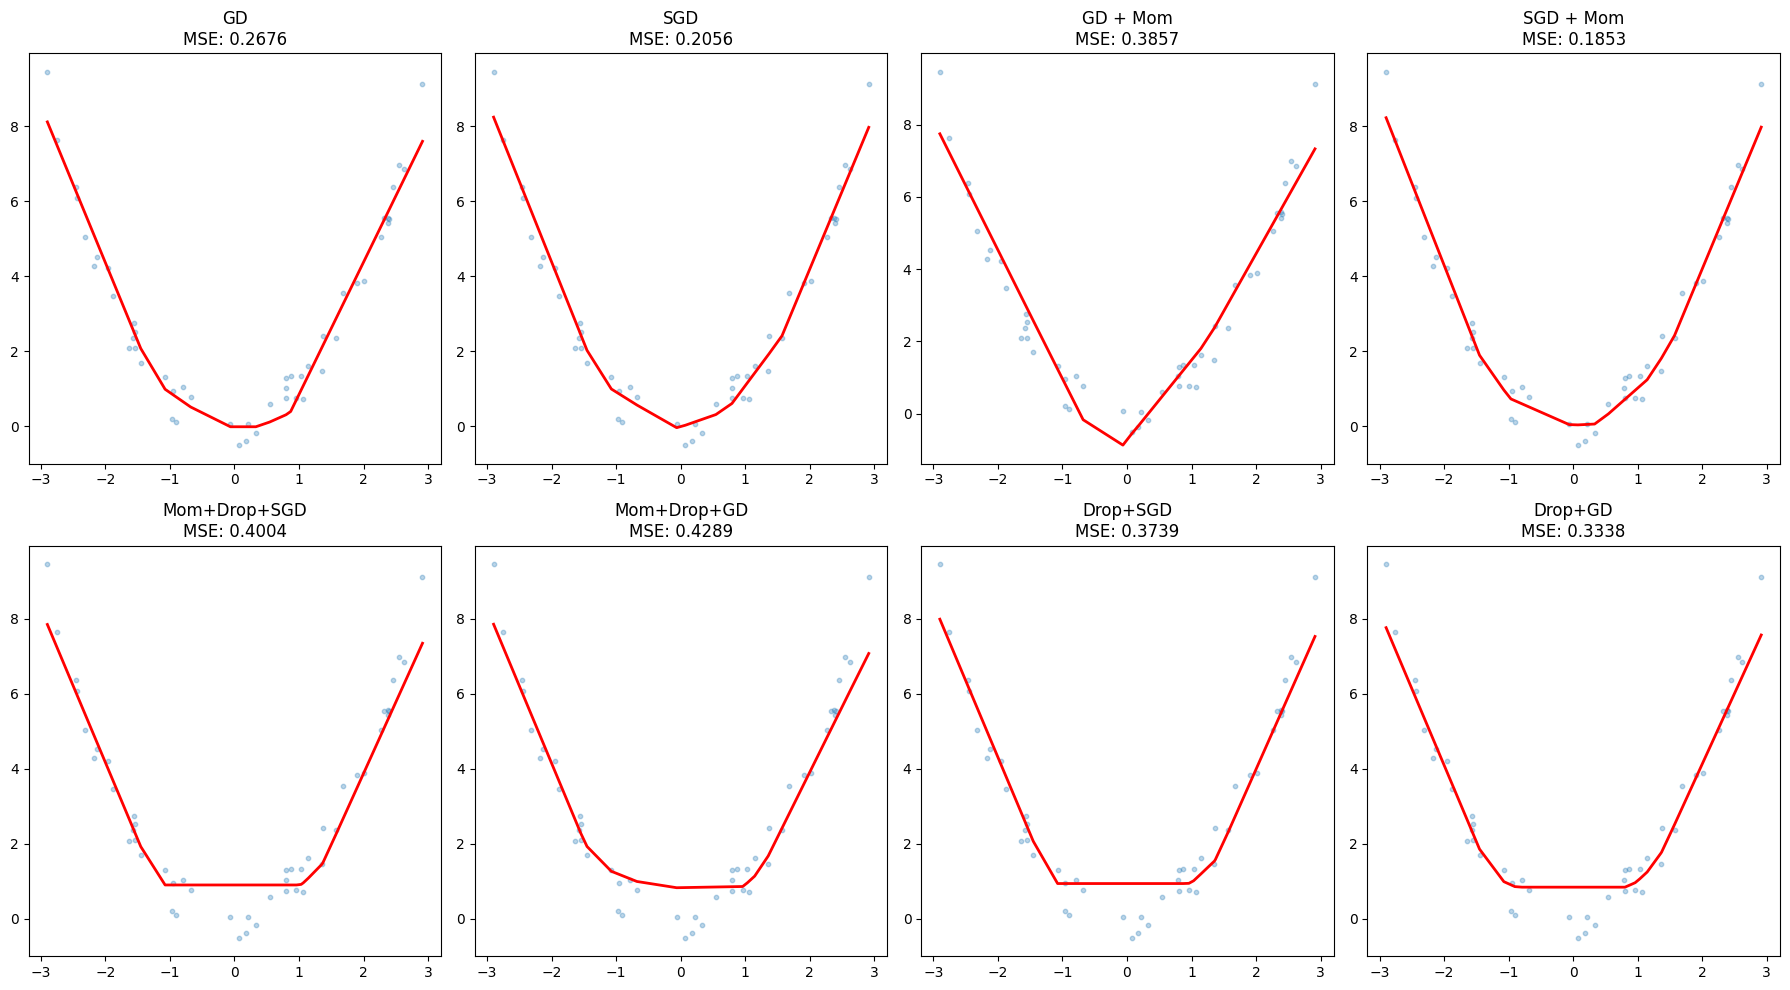

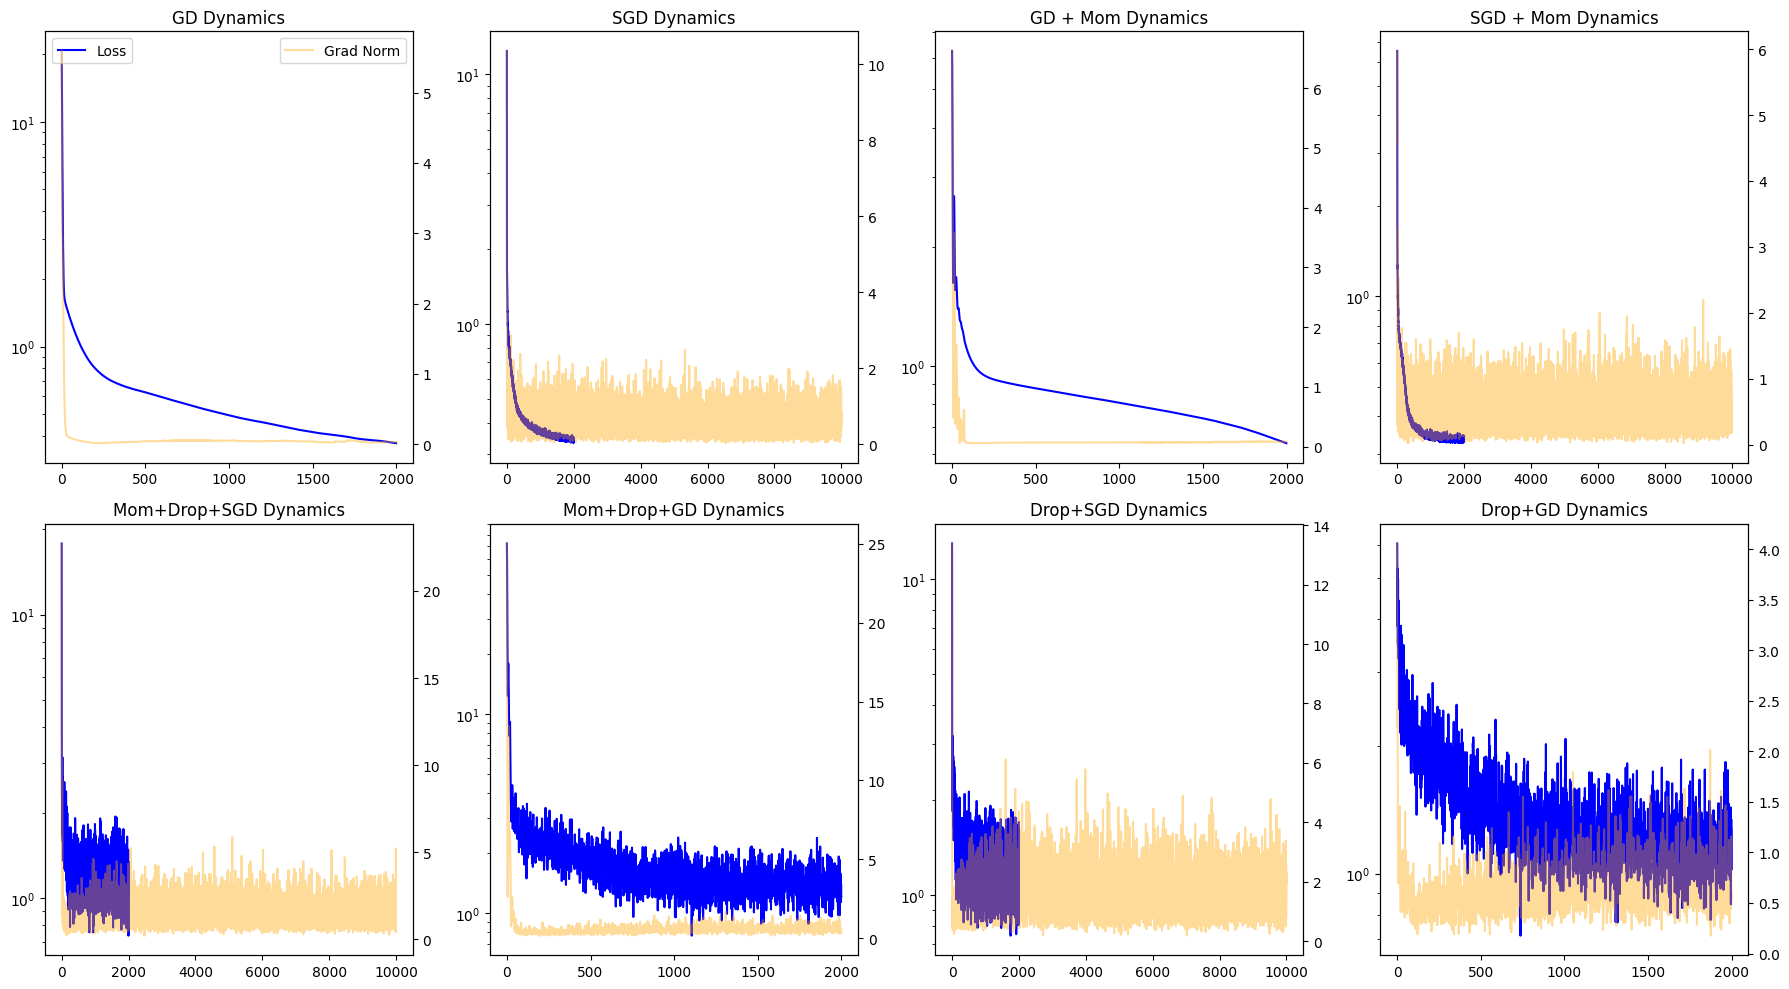

In [7]:
configs = [
    {"name": "GD", "use_sgd": False, "beta": 0.0, "keep": 1.0, "bs": 150},
    {"name": "SGD", "use_sgd": True, "beta": 0.0, "keep": 1.0, "bs": 32},
    {"name": "GD + Mom", "use_sgd": False, "beta": 0.9, "keep": 1.0, "bs": 150},
    {"name": "SGD + Mom", "use_sgd": True, "beta": 0.9, "keep": 1.0, "bs": 32},
    {"name": "Mom+Drop+SGD", "use_sgd": True, "beta": 0.9, "keep": 0.8, "bs": 32},
    {"name": "Mom+Drop+GD", "use_sgd": False, "beta": 0.9, "keep": 0.8, "bs": 150},
    {"name": "Drop+SGD", "use_sgd": True, "beta": 0.0, "keep": 0.8, "bs": 32},
    {"name": "Drop+GD", "use_sgd": False, "beta": 0.0, "keep": 0.8, "bs": 150}
]

fig_fit, axes_fit = plt.subplots(2, 4, figsize=(18, 10))
fig_dyn, axes_dyn = plt.subplots(2, 4, figsize=(18, 10))

for i, conf in enumerate(configs):
    nn = NeuralNetwork(1, 10, lr=0.01, reg_str=0.01, keep_prob=conf['keep'])
    nn.beta = conf['beta']
    
    if conf['use_sgd']:
        losses = nn.fit_sgd(X_train, y_train, epochs=2000, batch_size=conf['bs'], verbose=False)
    else:
        losses = nn.fit(X_train, y_train, epochs=2000, verbose=False)
    
    y_pred = nn.predict(X_test)
    mse = np.mean((y_pred - y_test)**2)
    
    print(f"Config: {conf['name']} | Test MSE: {mse:.6f}")

    # Plot Fit
    ax_f = axes_fit[i//4, i%4]
    ax_f.scatter(X_test, y_test, s=10, alpha=0.3)
    sort_idx = np.argsort(X_test.flatten())
    ax_f.plot(X_test[sort_idx], y_pred[sort_idx], 'r', lw=2)
    ax_f.set_title(f"{conf['name']}\nMSE: {mse:.4f}")

    # Plot Dynamics (Loss and Grad Norm)
    ax_d = axes_dyn[i//4, i%4]
    ax_d.plot(losses, label='Loss', color='blue')
    ax_d.set_yscale('log')
    ax_grad = ax_d.twinx()
    ax_grad.plot(nn.history['grad_norm_W1'], label='Grad Norm', color='orange', alpha=0.4)
    ax_d.set_title(f"{conf['name']} Dynamics")
    if i == 0: ax_d.legend(loc='upper left'); ax_grad.legend(loc='upper right')

fig_fit.tight_layout()
fig_dyn.tight_layout()
plt.show()

Config: Beta 0.5 (Low Mom)   | Test MSE: 0.190494
Config: Beta 0.9 (Mid Mom)   | Test MSE: 0.199796
Config: Beta 0.99 (High Mom) | Test MSE: 0.205177
Config: BS 8 (High Noise)    | Test MSE: 0.194461
Config: BS 128 (Low Noise)   | Test MSE: 0.206172
Config: Hidden 10 (No Drop)  | Test MSE: 0.201620
Config: Hidden 50 (No Drop)  | Test MSE: 0.191906
Config: Hidden 50 (Drop 0.5) | Test MSE: 0.318469


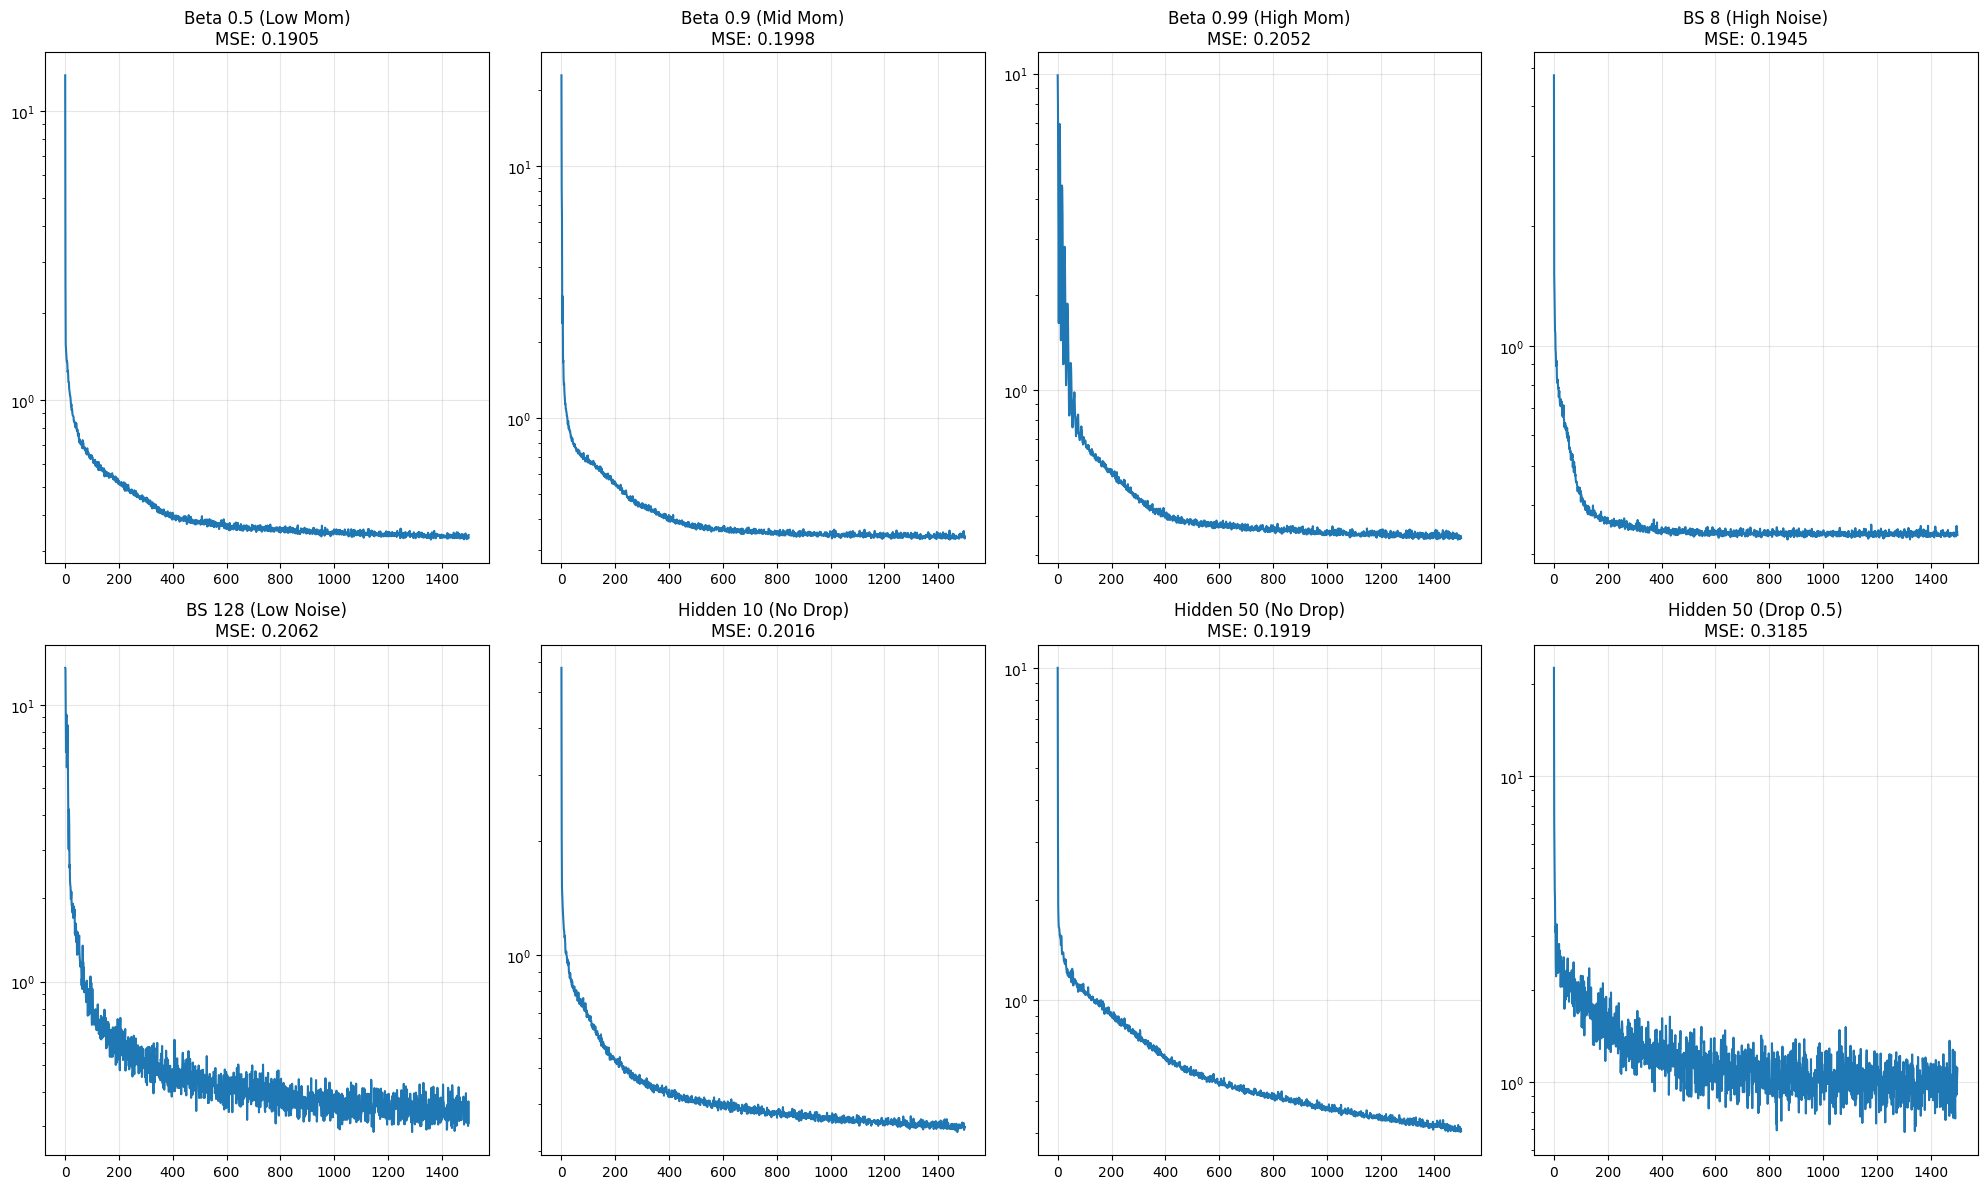

In [10]:
configs = [
    #Momentum Sensitivity (using fixed BS=32, Hidden=10)
    {"name": "Beta 0.5 (Low Mom)", "h_dim": 10, "beta": 0.5, "keep": 1.0, "bs": 32},
    {"name": "Beta 0.9 (Mid Mom)", "h_dim": 10, "beta": 0.9, "keep": 1.0, "bs": 32},
    {"name": "Beta 0.99 (High Mom)", "h_dim": 10, "beta": 0.99, "keep": 1.0, "bs": 32},
    
    #Batch Size Impact (using fixed Beta=0.7, Hidden=10)
    {"name": "BS 8 (High Noise)", "h_dim": 10, "beta": 0.7, "keep": 1.0, "bs": 8},
    {"name": "BS 128 (Low Noise)", "h_dim": 10, "beta": 0.7, "keep": 1.0, "bs": 128},
    
    #  Capacity & Dropout (using fixed BS=32, Beta=0.7)
    {"name": "Hidden 10 (No Drop)", "h_dim": 10, "beta": 0.7, "keep": 1.0, "bs": 32},
    {"name": "Hidden 50 (No Drop)", "h_dim": 50, "beta": 0.7, "keep": 1.0, "bs": 32},
    {"name": "Hidden 50 (Drop 0.5)", "h_dim": 50, "beta": 0.7, "keep": 0.5, "bs": 32}
]
plt.figure(figsize=(20, 12))

for i, conf in enumerate(configs):
    nn = NeuralNetwork(input_dim=1, hidden_dim=conf['h_dim'], lr=0.01, reg_str=0.01, keep_prob=conf['keep'])
    nn.beta = conf['beta']
    losses = nn.fit_sgd(X_train, y_train, epochs=1500, batch_size=conf['bs'], verbose=False)
    y_pred = nn.predict(X_test)
    mse = np.mean((y_pred - y_test)**2)
    print(f"Config: {conf['name']:<20} | Test MSE: {mse:.6f}")
    plt.subplot(2, 4, i+1)
    plt.plot(losses, label='Loss')
    plt.yscale('log')
    plt.title(f"{conf['name']}\nMSE: {mse:.4f}")
    plt.grid(True, alpha=0.3)
    

plt.tight_layout()
plt.show()

In [ ]:
# SGD noise helps: Small batches beat large batches on test error
# Momentum is a tradeoff: Too much smoothing reduces exploration
# Dropout is overkill here: Need way more capacity than 50 units for dropout to help
# GD: Smooth decay -> stable, deterministic
# SGD: High variance -> noisy, but this noise is good
# Dropout: Even higher variance -> too much noise, hurting convergence
# Momentum is exponentially moving average, over time the noise that helped explore gets dampened, if beta too high it snowballs
# Dropout is designed to stop co-adaptation in massive networks, not to help small models learn simple math.  
# Small batches is less accurate for the whole set but also more varied, naturally helping against overfitting